

# Transfer Learning on E. coli to S. aureus

#### Mukundan Thanigaivelan, <thanigam@union.edu>

#### June 12, 2026

This notebook contains work on training Denoising Autoencoders on E. coli RNA-Seq data, and fine-tuning these models on S. aureus data to assess if transfer learning helps the model learn S. aureus pathways.

#### Outline

0. Before anything, we connect to the GitHub repository.
1. First we'll load classes from adage and modules for plotting, etc.
2. Next we'll take a look at the training data!
3. Train some models with hyperparameters from previous search.
4. Plot training loss over epochs.
5. Plot weight distributions of final models.

## 0. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

Cloning into 'seqADAGE'...
remote: Enumerating objects: 426, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 426 (delta 51), reused 50 (delta 17), pack-reused 323 (from 1)
Receiving objects: 100% (426/426), 43.73 MiB | 35.94 MiB/s, done.
Resolving deltas: 100% (204/204), done.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning

/content/seqADAGE/Py/muk_transfer_learning


In [3]:
!pip install -qq tensorflow keras statsmodels seaborn plotnine_prism

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.0/346.0 kB 32.5 MB/s eta 0:00:00


## 1. Loading classes, modules

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [6]:
# ADAGE
from adage import Adage as ad
from adage import SeqAdage

# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from plotnine_prism import *

# Miscellaneous
import time
import tensorflow as tf
# from scipy.stats import hypergeom
# import csv
# import random

In [7]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 2. Training Data - EDA

Here we are looking at two training datasets. The first only has genes
in MG1655 and the second has genes in either MG1655 or a couple isolates
of interest (to include eloD genes).

### MG1655 genes

This compendium only has genes in MG1655 and samples have been filtered
by sparsity and housekeeping gene expression.

The data has been log transformed and scaled to be between 0 and 1.

#### Preparation

In [8]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [9]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 4272 genes (features) and 16150 samples


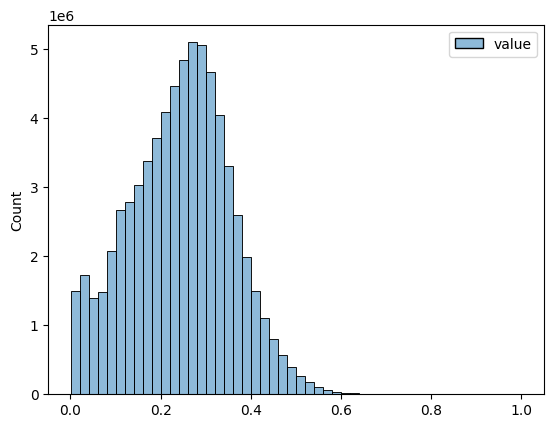

In [10]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

#### Gene-wise Filtering

In [11]:
# Get gene sample statistics
gene_stats = all_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
11997cc26382b2c286cd502685a104a5_13,16150.0,0.290959,0.049891,0.005090,0.263131,0.284746,0.309190,0.571206
11997cc26382b2c286cd502685a104a5_45,16150.0,0.277920,0.057231,0.002175,0.261675,0.284082,0.305577,0.597320
11997cc26382b2c286cd502685a104a5_102,16150.0,0.213072,0.107602,0.000692,0.119966,0.243526,0.290658,0.742326
11997cc26382b2c286cd502685a104a5_110,16150.0,0.312207,0.066389,0.032919,0.295633,0.324393,0.347428,0.754336
11997cc26382b2c286cd502685a104a5_72,16150.0,0.364656,0.082157,0.022983,0.299426,0.356862,0.427053,0.715735


Text(0.5, 1.0, 'Variance vs. Mean expression')

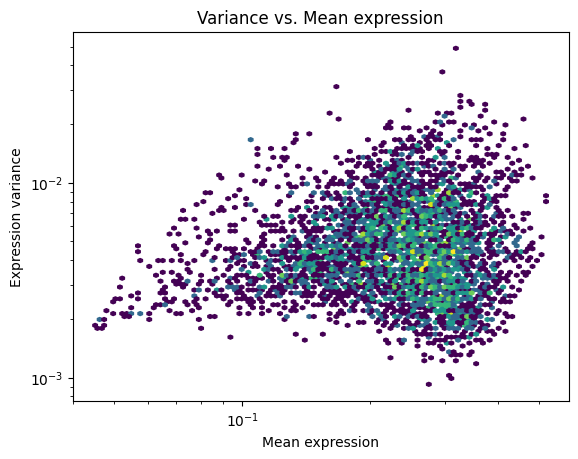

In [12]:
# Preliminary hexagonal binning log-scaled plot of variance versus mean
plt.hexbin(
  x = gene_stats['mean'],
  y = gene_stats['std'] ** 2,
  bins='log',
  xscale='log',
  yscale='log'
)
plt.xlabel("Mean expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. Mean expression")

<Axes: xlabel='std', ylabel='Count'>

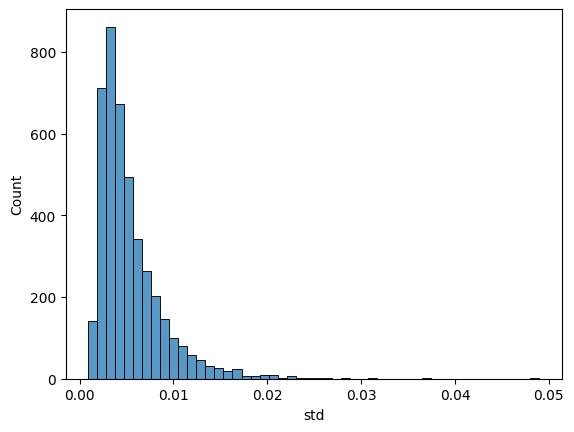

In [13]:
# Plot variance distribution
sns.histplot(gene_stats['std'] ** 2, bins = 50)

In [14]:
# Get 25th percentile cutoff
var_cutoff = np.percentile(gene_stats['std'] ** 2, 25)

# Pull bottom 25% variance genes
low_var_genes = gene_stats[gene_stats['std'] ** 2 < var_cutoff]

low_var_genes.shape

(1068, 8)

<Axes: xlabel='mean', ylabel='Count'>

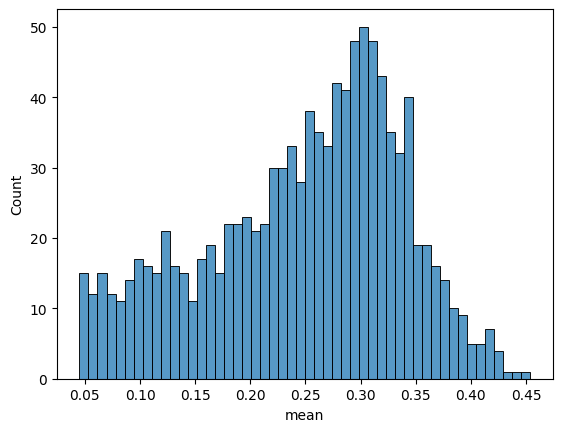

In [15]:
low_var_genes = all_comp.T[low_var_genes.index].describe().T
sns.histplot(low_var_genes['mean'], bins = 50)

In [16]:
# Get 40th percentile cutoff
mean_cutoff = np.percentile(low_var_genes['mean'], 40)

# Pull bottom 40% mean genes
genes_to_rm = low_var_genes[low_var_genes['mean'] < mean_cutoff]

genes_to_rm.shape

(427, 8)

Text(0.5, 1.0, 'Variance vs. Mean expression')

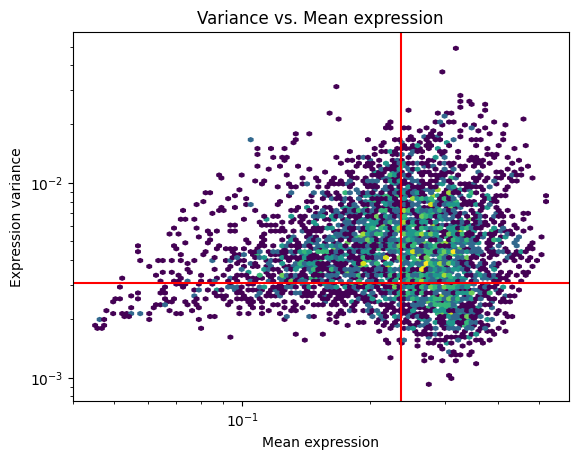

In [17]:
# Hexagonal binning log-scaled plot of variance versus mean - lower left quadrant represents
# genes to filter out
plt.hexbin(
  x = gene_stats['mean'],
  y = gene_stats['std'] ** 2,
  bins='log',
  xscale='log',
  yscale='log'
)
plt.axvline(genes_to_rm['mean'].max(), color = 'red')
plt.axhline((genes_to_rm['std'] ** 2).max(), color = 'red')

plt.xlabel("Mean expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. Mean expression")

In [18]:
filtered_genes = all_comp.drop(genes_to_rm.index, axis = 0)
filtered_genes.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644788.salmon,...,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon,SRX28568289.salmon
11997cc26382b2c286cd502685a104a5_13,0.234579,0.254150,0.243907,0.243012,0.235899,0.280912,0.264422,0.270019,0.317142,0.299569,...,0.298677,0.276767,0.351828,0.337247,0.312398,0.321875,0.321036,0.318821,0.311354,0.304692
11997cc26382b2c286cd502685a104a5_45,0.272709,0.262344,0.276821,0.249772,0.268399,0.265376,0.257609,0.264961,0.292222,0.299569,...,0.299682,0.305974,0.262008,0.261497,0.286625,0.293051,0.290033,0.296570,0.277161,0.276499
11997cc26382b2c286cd502685a104a5_102,0.037627,0.026616,0.025180,0.039842,0.027814,0.049805,0.019763,0.050739,0.144859,0.160183,...,0.278582,0.273690,0.302600,0.296838,0.335073,0.335004,0.331882,0.327804,0.308324,0.290361
11997cc26382b2c286cd502685a104a5_110,0.323079,0.320358,0.293970,0.311448,0.291142,0.281595,0.328269,0.314841,0.311958,0.305564,...,0.342191,0.338557,0.351999,0.363475,0.374065,0.357845,0.361081,0.365622,0.347532,0.342460
11997cc26382b2c286cd502685a104a5_72,0.305784,0.336823,0.276244,0.339746,0.291997,0.300844,0.333681,0.289742,0.420649,0.399211,...,0.490506,0.479772,0.329882,0.318733,0.428194,0.428926,0.428631,0.431648,0.540901,0.509258


#### Experiment-wise Filtering

In [19]:
# Get experiment statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
ERX358242.salmon,3845.0,0.257266,0.087268,0.037627,0.205983,0.260780,0.311812,0.538706
ERX358243.salmon,3845.0,0.256635,0.093092,0.026616,0.200639,0.261310,0.316472,0.536585
ERX358244.salmon,3845.0,0.256851,0.090081,0.025180,0.205304,0.260760,0.314951,0.527667
ERX358245.salmon,3845.0,0.257802,0.091911,0.039842,0.203801,0.263559,0.318501,0.559430
ERX358246.salmon,3845.0,0.256920,0.094988,0.027814,0.199931,0.260512,0.319577,0.549574


Text(0.5, 1.0, 'Variance vs. median expression')

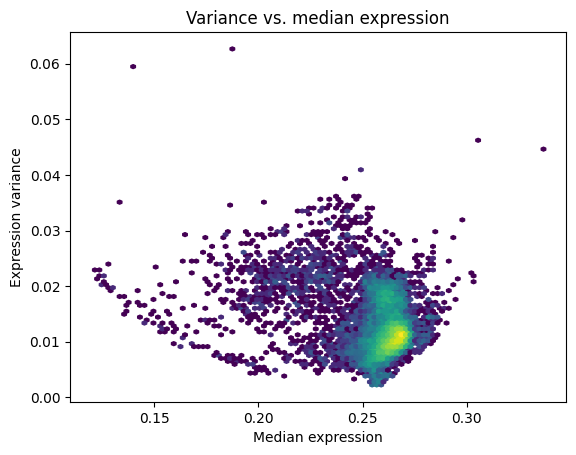

In [20]:
# Prelimiary plot of variance by median expression
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['std'] ** 2,
  bins = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. median expression")

<Axes: xlabel='std', ylabel='Count'>

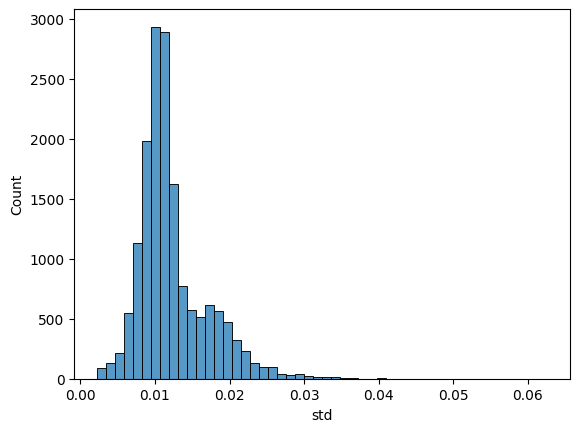

In [21]:
# Plot variance distribution
sns.histplot(exp_stats['std'] ** 2, bins = 50)

In [22]:
# Get 25th percentile cutoff
var_cutoff = np.percentile(exp_stats['std'] ** 2, 25)

# Pull bottom 25% variance samples
low_var_exps = exp_stats[exp_stats['std'] ** 2 < var_cutoff]

low_var_exps.shape

(4038, 8)

<Axes: xlabel='50%', ylabel='Count'>

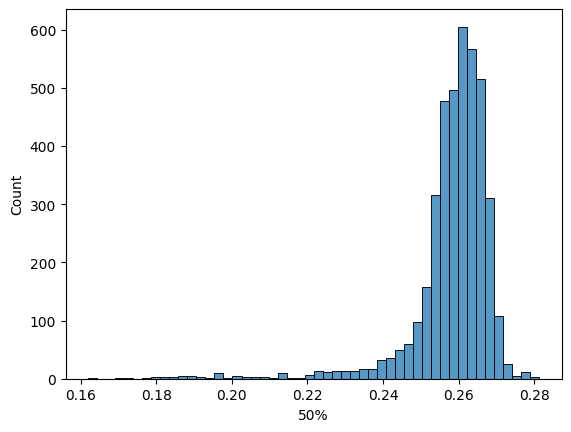

In [23]:
# Get statistics on low variance experiments
low_var_exps = filtered_genes[low_var_exps.index].describe().T
sns.histplot(low_var_exps['50%'], bins = 50)

In [24]:
# Get 40th percentile cutoff
med_cutoff = np.percentile(low_var_exps['50%'], 40)

# Pull bottom 40% median samples
exps_to_rm = low_var_exps[low_var_exps['50%'] < med_cutoff]

exps_to_rm.shape

(1615, 8)

Text(0.5, 1.0, 'Variance vs. median expression')

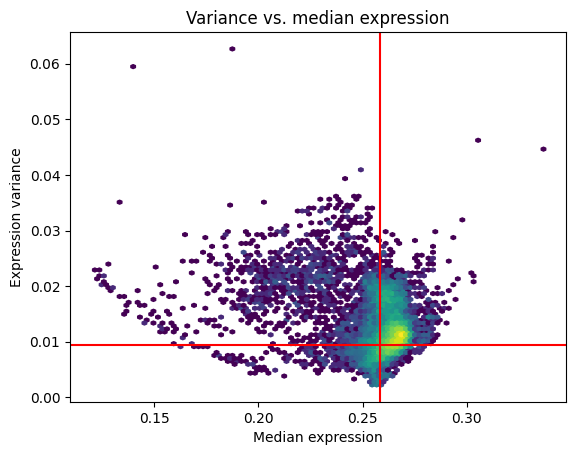

In [25]:
# Make a plot with boundaries for filtering out samples - lower left quadrant
# will be dropped
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['std'] ** 2,
  bins = 'log'
)
plt.axvline(exps_to_rm['50%'].max(), color = 'red')
plt.axhline((exps_to_rm['std']**2).max(), color = 'red')

plt.xlabel("Median expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. median expression")

In [26]:
# Obtain final filtered dataset
filtered_df = filtered_genes.drop(exps_to_rm.index, axis = 1)
filtered_df.shape

(3845, 14535)

### MG1655+ genes

This compendium has genes in MG1655 or a couple other strains/isoaltes
and samples have been filtered by sparsity and housekeeping gene
expression, but are expected to be more sparse given the presence of
strain-specific accessory genes.

The data has been log transformed and scaled to be between 0 and 1.

#### Preparation

In [27]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmgp_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [28]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 6390 genes (features) and 16122 samples


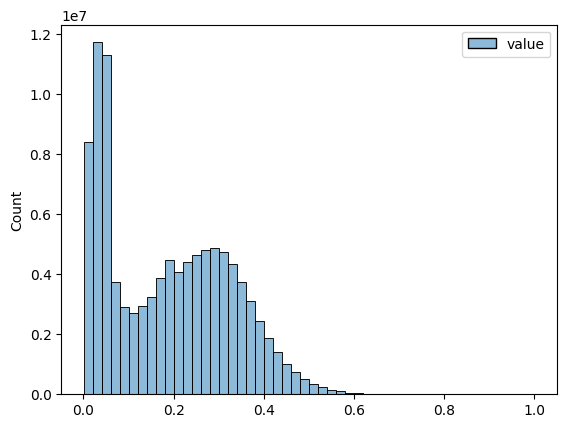

In [29]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

#### Gene-wise Filtering

In [30]:
# Get gene sample statistics
gene_stats = all_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
0ed86576d343ce011a61773e0620e335_1041,16122.0,0.077232,0.075301,0.000886,0.024035,0.042847,0.122534,0.534683
0ed86576d343ce011a61773e0620e335_1045,16122.0,0.087295,0.057721,0.003279,0.043884,0.072425,0.116301,0.487094
0ed86576d343ce011a61773e0620e335_1476,16122.0,0.163536,0.077092,0.002585,0.103627,0.179839,0.213743,0.473169
0ed86576d343ce011a61773e0620e335_1484,16122.0,0.069370,0.056209,0.000886,0.025019,0.046082,0.108003,0.470536
0ed86576d343ce011a61773e0620e335_2130,16122.0,0.088783,0.051069,0.004582,0.048053,0.079310,0.117704,0.431915


Text(0.5, 1.0, 'Variance vs. Mean expression')

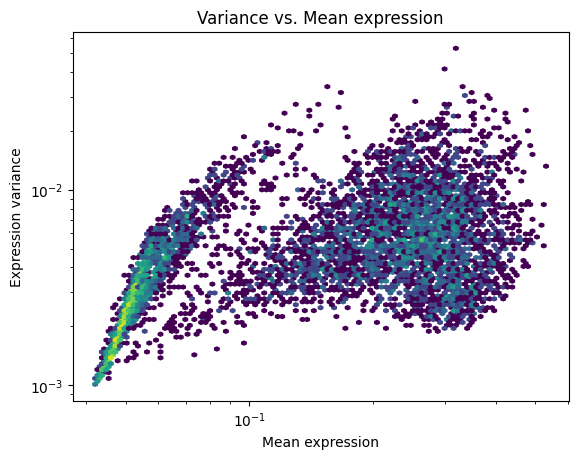

In [31]:
# Preliminary hexagonal binning log-scaled plot of variance versus mean
plt.hexbin(
  x = gene_stats['mean'],
  y = gene_stats['std'] ** 2,
  bins='log',
  xscale='log',
  yscale='log'
)
plt.xlabel("Mean expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. Mean expression")

<Axes: xlabel='std', ylabel='Count'>

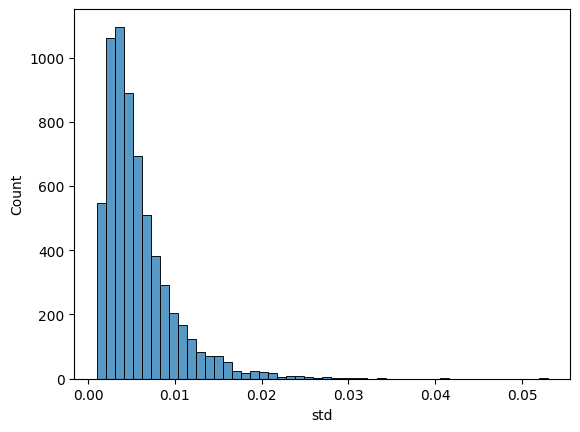

In [32]:
# Plot variance distribution
sns.histplot(gene_stats['std'] ** 2, bins = 50)

In [33]:
# Get 25th percentile cutoff
var_cutoff = np.percentile(gene_stats['std'] ** 2, 25)

# Pull bottom 25% variance genes
low_var_genes = gene_stats[gene_stats['std'] ** 2 < var_cutoff]

low_var_genes.shape

(1598, 8)

<Axes: xlabel='mean', ylabel='Count'>

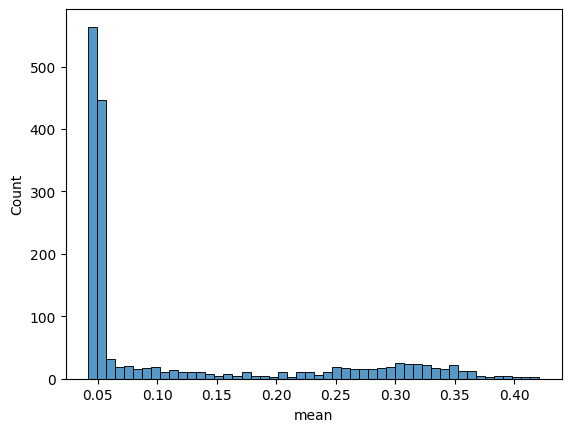

In [34]:
low_var_genes = all_comp.T[low_var_genes.index].describe().T
sns.histplot(low_var_genes['mean'], bins = 50)

In [35]:
# Get 40th percentile cutoff
mean_cutoff = np.percentile(low_var_genes['mean'], 40)

# Pull bottom 40% mean genes
genes_to_rm = low_var_genes[low_var_genes['mean'] < mean_cutoff]

genes_to_rm.shape

(639, 8)

Text(0.5, 1.0, 'Variance vs. Mean expression')

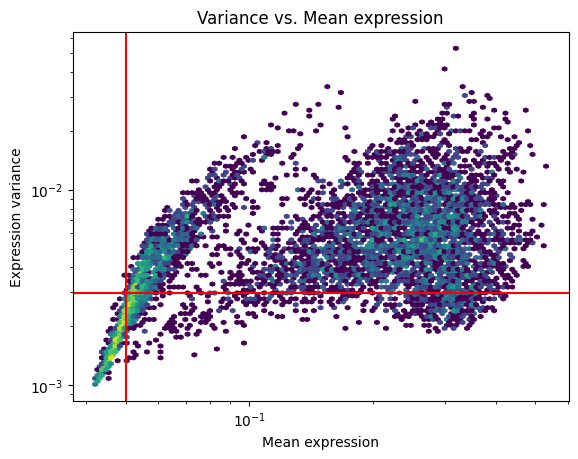

In [36]:
# Hexagonal binning log-scaled plot of variance versus mean - lower left quadrant represents
# genes to filter out
plt.hexbin(
  x = gene_stats['mean'],
  y = gene_stats['std'] ** 2,
  bins='log',
  xscale='log',
  yscale='log'
)
plt.axvline(genes_to_rm['mean'].max(), color = 'red')
plt.axhline((genes_to_rm['std'] ** 2).max(), color = 'red')

plt.xlabel("Mean expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. Mean expression")

In [37]:
filtered_genes = all_comp.drop(genes_to_rm.index, axis = 0)
filtered_genes.head()

,ERX358243,ERX358244,ERX358245,ERX358246,ERX358247,ERX358248,ERX358249,ERX644787,ERX644788,ERX644789,...,SRX28568279,SRX28568280,SRX28568281,SRX28568282,SRX28568283,SRX28568284,SRX28568285,SRX28568286,SRX28568287,SRX28568288
0ed86576d343ce011a61773e0620e335_1041,0.171148,0.037750,0.042322,0.039481,0.045178,0.030353,0.234787,0.115597,0.128144,0.127795,...,0.014785,0.010631,0.015451,0.025898,0.020627,0.037324,0.174210,0.037212,0.184049,0.026891
0ed86576d343ce011a61773e0620e335_1045,0.132580,0.215529,0.131003,0.178620,0.085422,0.098022,0.108496,0.115597,0.128144,0.127795,...,0.014785,0.010631,0.015451,0.025898,0.056321,0.074138,0.031145,0.037212,0.037601,0.026891
0ed86576d343ce011a61773e0620e335_1476,0.291676,0.313923,0.311423,0.323608,0.228029,0.310924,0.045566,0.169165,0.128144,0.127795,...,0.183638,0.198502,0.200135,0.176668,0.188772,0.197787,0.182673,0.188009,0.096002,0.190439
0ed86576d343ce011a61773e0620e335_1484,0.037630,0.037750,0.170422,0.039481,0.045178,0.030353,0.136272,0.115597,0.128144,0.127795,...,0.014785,0.010631,0.015451,0.025898,0.020627,0.110703,0.031145,0.037212,0.037601,0.026891
0ed86576d343ce011a61773e0620e335_2130,0.195812,0.234322,0.136092,0.135860,0.045178,0.118685,0.187253,0.115597,0.128144,0.127795,...,0.075937,0.068542,0.085528,0.025898,0.020627,0.074138,0.031145,0.037212,0.074549,0.044574


#### Experiment-wise Filtering

In [38]:
# Get experiment statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
ERX358243,5751.0,0.218121,0.132353,0.037630,0.037630,0.240617,0.318823,0.573332
ERX358244,5751.0,0.222363,0.132140,0.037750,0.037750,0.248609,0.320782,0.568117
ERX358245,5751.0,0.205618,0.123831,0.042322,0.042322,0.222121,0.299487,0.576927
ERX358246,5751.0,0.218999,0.133076,0.039481,0.039481,0.239469,0.320323,0.587245
ERX358247,5751.0,0.194287,0.128073,0.045178,0.045178,0.190525,0.296162,0.611175


Text(0.5, 1.0, 'Variance vs. median expression')

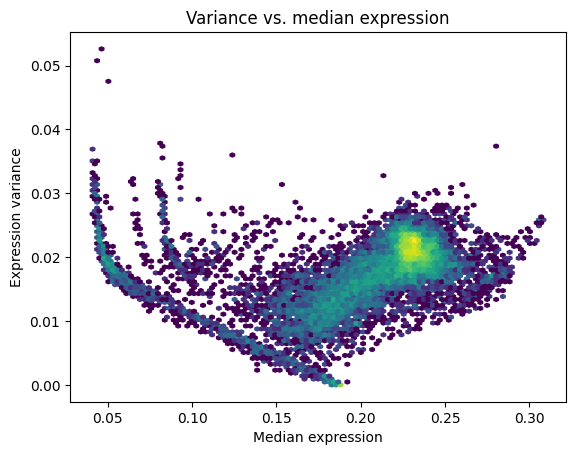

In [39]:
# Prelimiary plot of variance by median expression
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['std'] ** 2,
  bins = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. median expression")

<Axes: xlabel='std', ylabel='Count'>

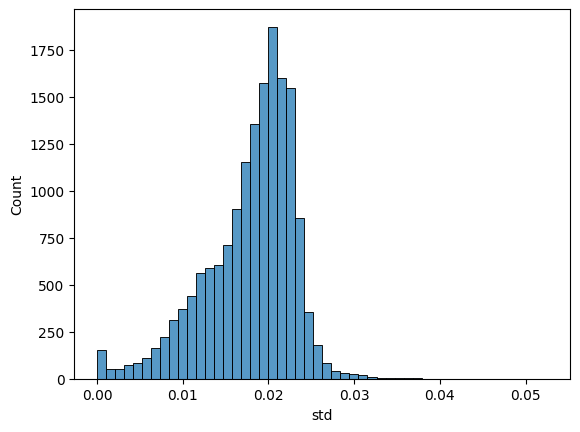

In [40]:
# Plot variance distribution
sns.histplot(exp_stats['std'] ** 2, bins = 50)

In [41]:
# Get 25th percentile cutoff
var_cutoff = np.percentile(exp_stats['std'] ** 2, 25)

# Pull bottom 25% variance samples
low_var_exps = exp_stats[exp_stats['std'] ** 2 < var_cutoff]

low_var_exps.shape

(4031, 8)

<Axes: xlabel='50%', ylabel='Count'>

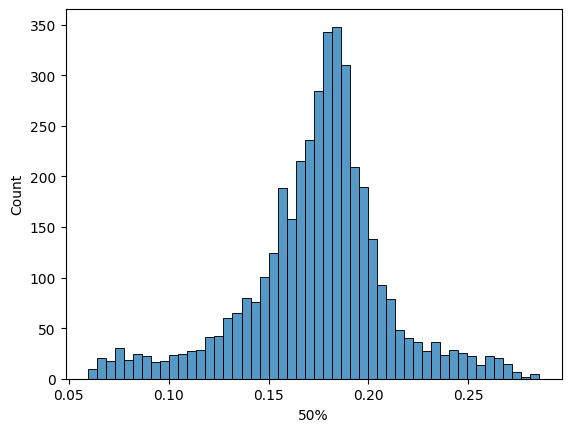

In [42]:
# Get statistics on low variance experiments
low_var_exps = filtered_genes[low_var_exps.index].describe().T
sns.histplot(low_var_exps['50%'], bins = 50)

In [43]:
# Get 40th percentile cutoff
med_cutoff = np.percentile(low_var_exps['50%'], 40)

# Pull bottom 40% median samples
exps_to_rm = low_var_exps[low_var_exps['50%'] < med_cutoff]

exps_to_rm.shape

(1612, 8)

Text(0.5, 1.0, 'Variance vs. median expression')

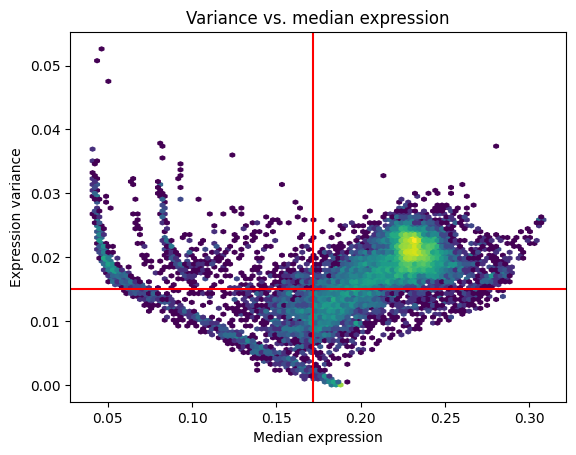

In [44]:
# Make a plot with boundaries for filtering out samples - lower left quadrant
# will be dropped
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['std'] ** 2,
  bins = 'log'
)
plt.axvline(exps_to_rm['50%'].max(), color = 'red')
plt.axhline((exps_to_rm['std']**2).max(), color = 'red')

plt.xlabel("Median expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. median expression")

In [45]:
# Obtain final filtered dataset
filtered_df = filtered_genes.drop(exps_to_rm.index, axis = 1)
filtered_df.shape

(5751, 14510)

### Dimensionality Reduction

#### PCA

In [46]:
from sklearn.decomposition import PCA

##### Reduce samples

In [49]:
X_pca = PCA(n_components=50).fit_transform(filtered_df)
df_pca = pd.DataFrame(X_pca)
df_pca.index = filtered_df.index
df_pca.columns = [f"PC{i}" for i in range(1, 51)]

In [50]:
df_pca.shape

(5751, 50)

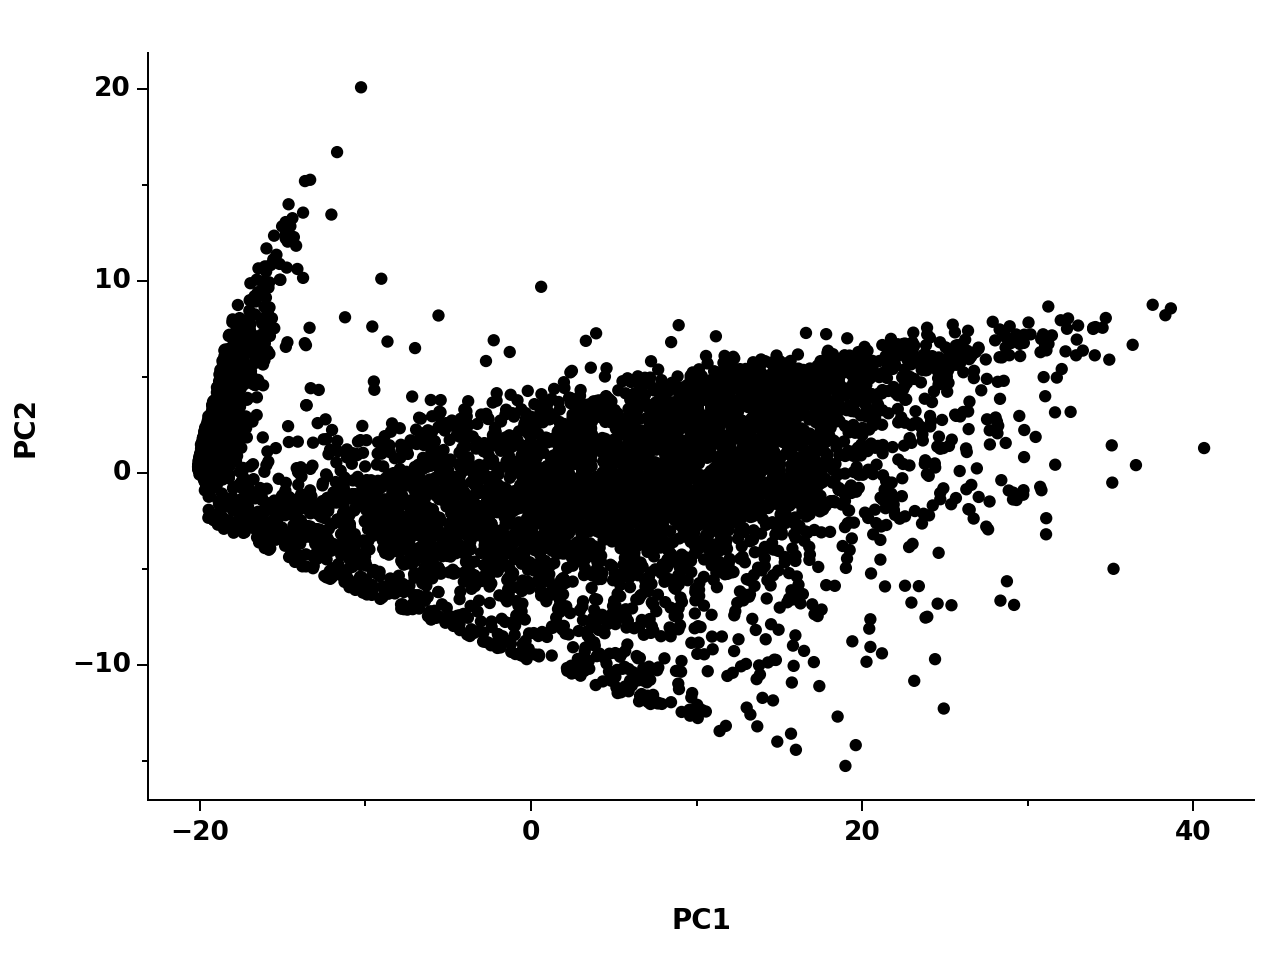

<Figure Size: (640 x 480)>

In [94]:
p1 = (
  ggplot(df_pca, aes(x="PC1", y="PC2"))
  + geom_point()
  + theme_prism()
)
p1

##### Reduce genes

In [53]:
Y_pca = PCA(n_components=50).fit_transform(filtered_df.T)
df_pca2 = pd.DataFrame(Y_pca)
df_pca2.index = filtered_df.columns
df_pca2.columns = [f"PC{i}" for i in range(1, 51)]

In [54]:
df_pca2.shape

(14510, 50)

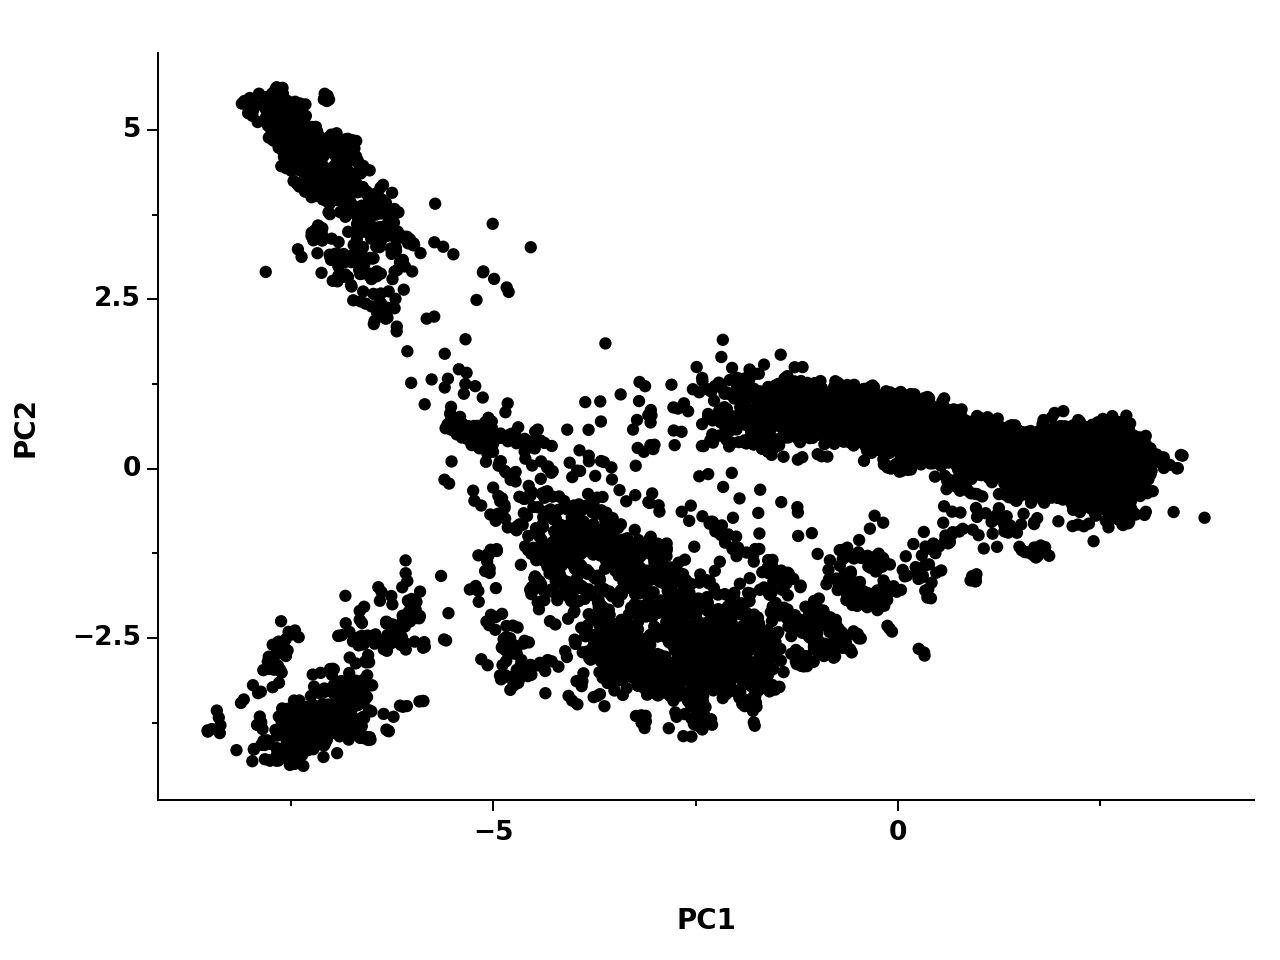

<Figure Size: (640 x 480)>

In [95]:
p2 = (
  ggplot(df_pca2, aes(x="PC1", y="PC2"))
  + geom_point()
  + theme_prism()
)
p2

#### t-SNE

In [56]:
from sklearn.manifold import TSNE

##### Reduce samples

In [57]:
X_tsne = TSNE(learning_rate=100).fit_transform(filtered_df)
df_tsne = pd.DataFrame(X_tsne)

In [58]:
df_tsne.columns = ["tSNE1", "tSNE2"]
df_tsne.index = filtered_df.index

In [59]:
df_tsne.shape

(5751, 2)

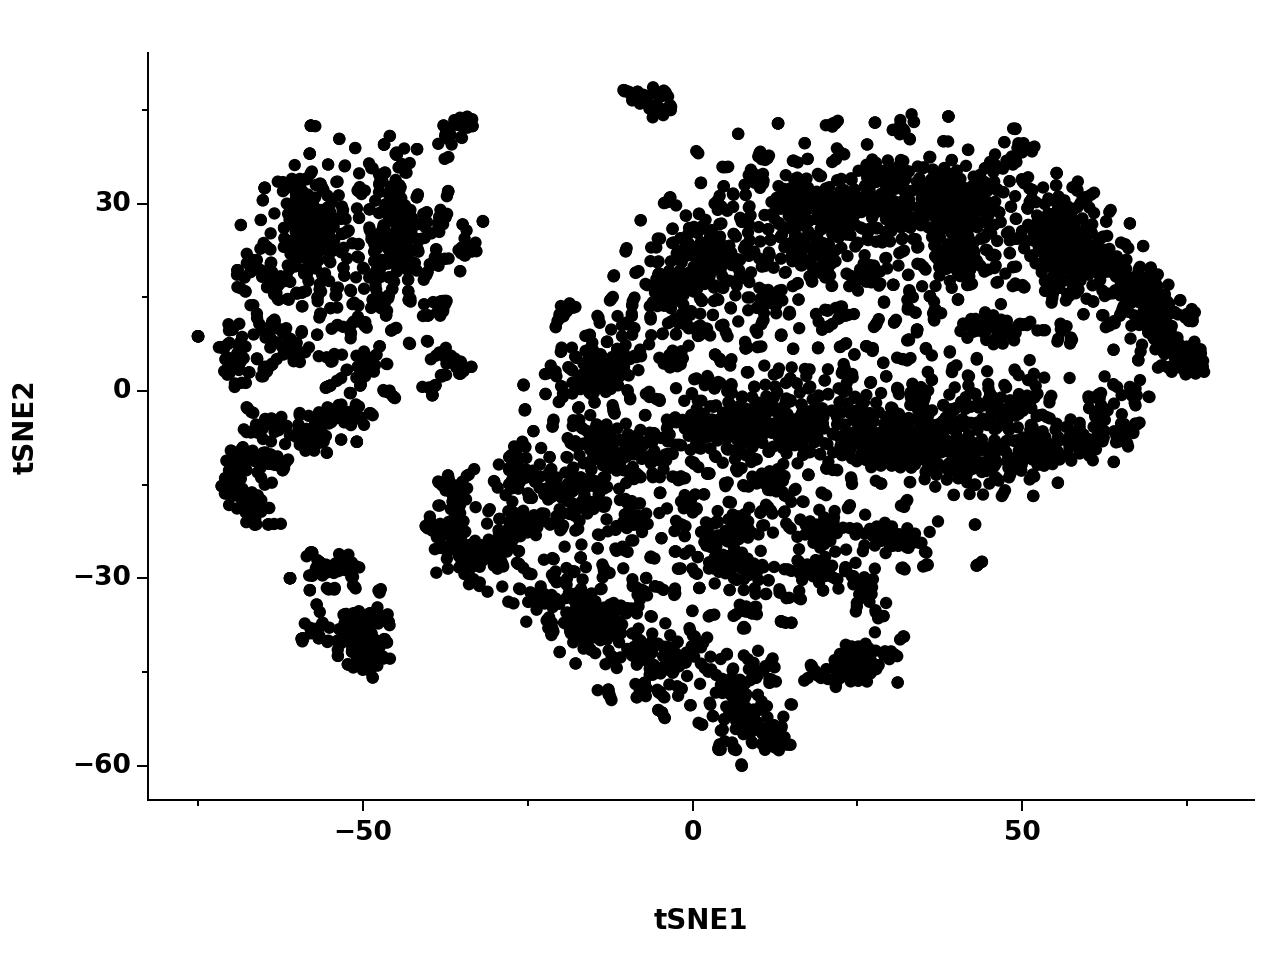

<Figure Size: (640 x 480)>

In [92]:
p3 = (
  ggplot(df_tsne, aes(x='tSNE1', y='tSNE2'))
  + geom_point()
  + theme_prism()
)
p3

##### Reduce genes

In [61]:
Y_tsne = TSNE(learning_rate=100).fit_transform(filtered_df.T)
df_tsne2 = pd.DataFrame(Y_tsne)

In [62]:
df_tsne2.columns = ["tSNE1", "tSNE2"]
df_tsne2.index = filtered_df.columns

In [63]:
df_tsne2.shape

(14510, 2)

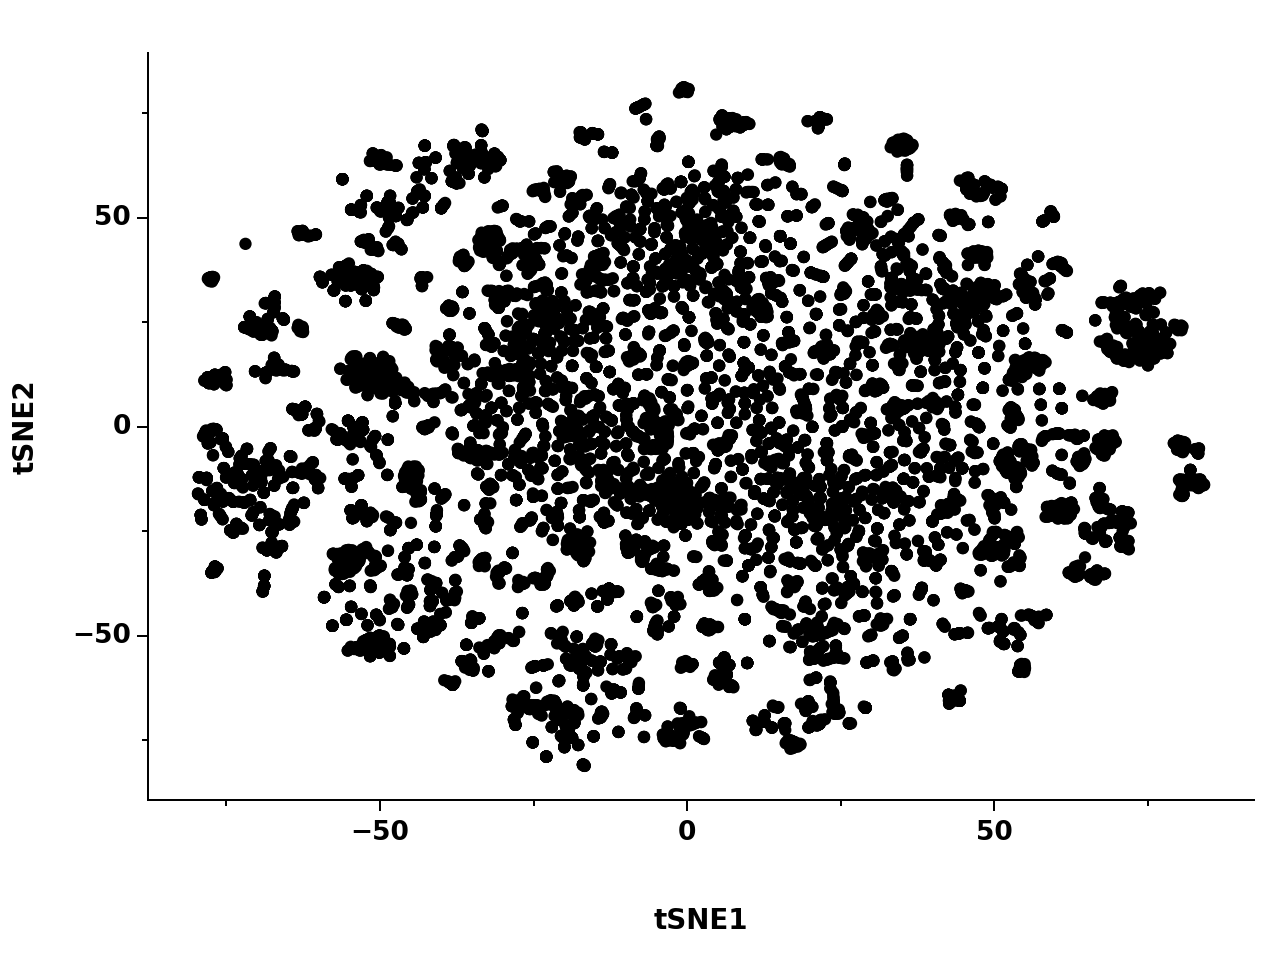

<Figure Size: (640 x 480)>

In [93]:
p4 = (
  ggplot(df_tsne2, aes(x='tSNE1', y='tSNE2'))
  + geom_point()
  + theme_prism()
)
p4

#### UMAP

In [65]:
from umap import UMAP

###### Reduce samples

In [66]:
X_umap = UMAP().fit_transform(filtered_df)

In [67]:
df_umap = pd.DataFrame(X_umap)
df_umap.columns = ['UMAP1', 'UMAP2']
df_umap.index = filtered_df.index

In [68]:
df_umap.shape

(5751, 2)

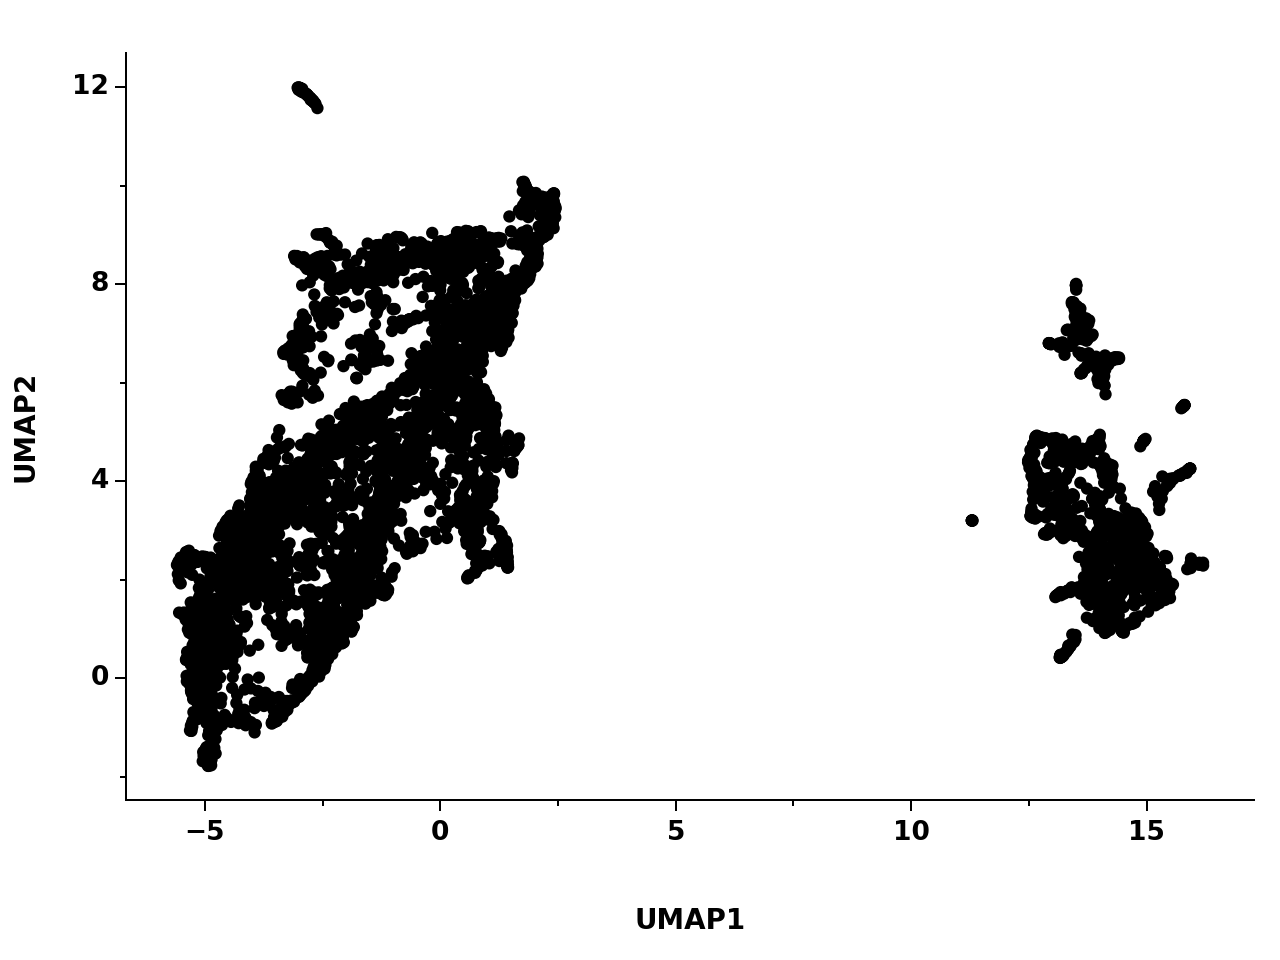

<Figure Size: (640 x 480)>

In [90]:
p5 = (
  ggplot(df_umap, aes(x='UMAP1', y='UMAP2'))
  + geom_point()
  + theme_prism()
)
p5

###### Reduce genes

In [70]:
Y_umap = UMAP().fit_transform(filtered_df.T)

In [71]:
df_umap2 = pd.DataFrame(Y_umap)
df_umap2.columns = ['UMAP1', 'UMAP2']
df_umap2.index = filtered_df.columns

In [72]:
df_umap2.shape

(14510, 2)

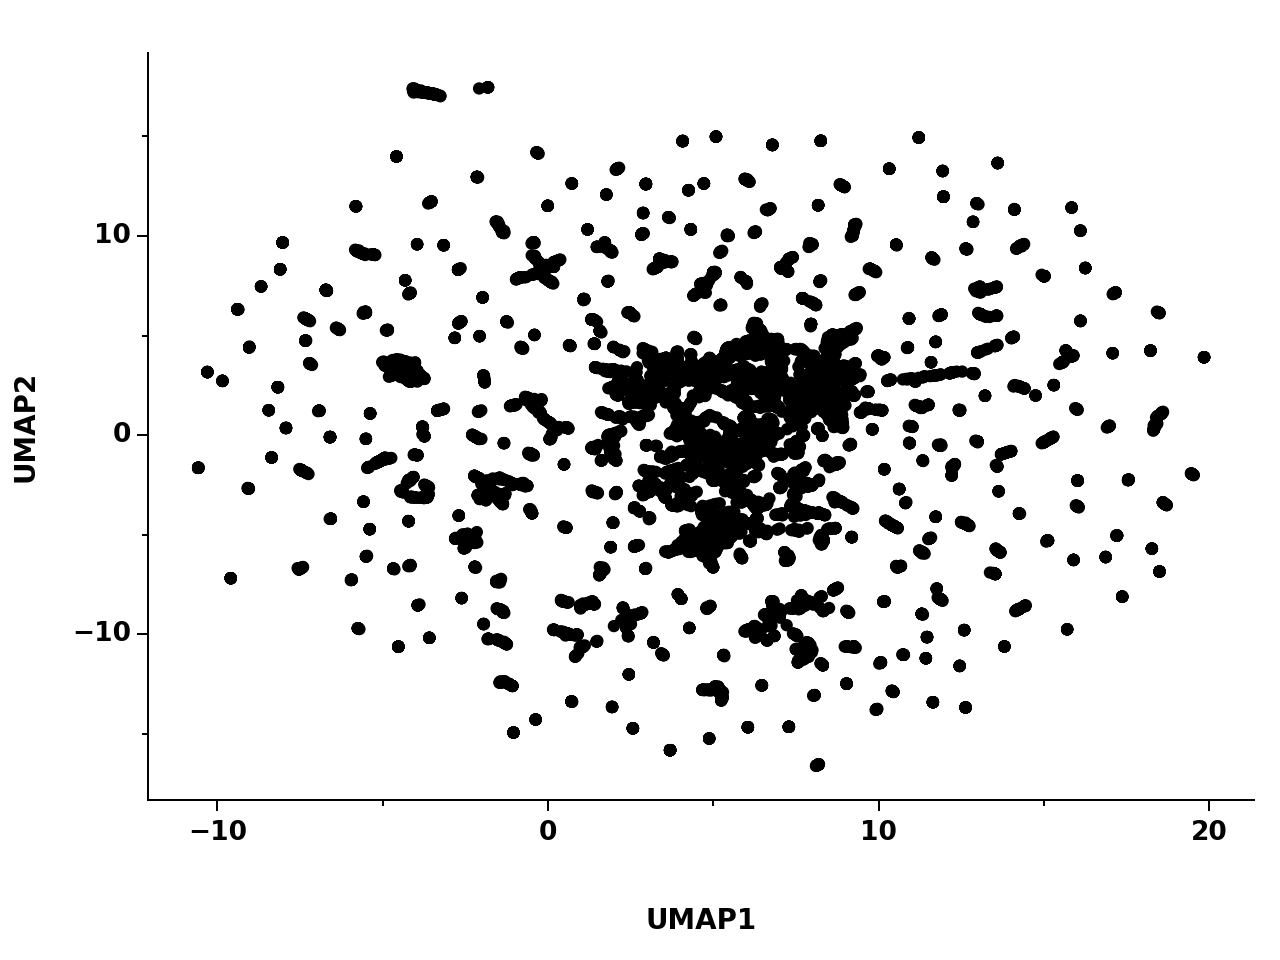

<Figure Size: (640 x 480)>

In [91]:
p6 = (
  ggplot(df_umap2, aes(x='UMAP1', y='UMAP2'))
  + geom_point()
  + theme_prism()
)
p6

#### ICA

In [74]:
from sklearn.decomposition import FastICA

###### Reduce samples

In [75]:
X_ica = FastICA(n_components=50).fit_transform(filtered_df)

In [78]:
df_ica = pd.DataFrame(X_ica)
df_ica.columns = [f"IC{i}" for i in range(1, 51)]
df_ica.index = filtered_df.index

In [79]:
df_ica.shape

(5751, 50)

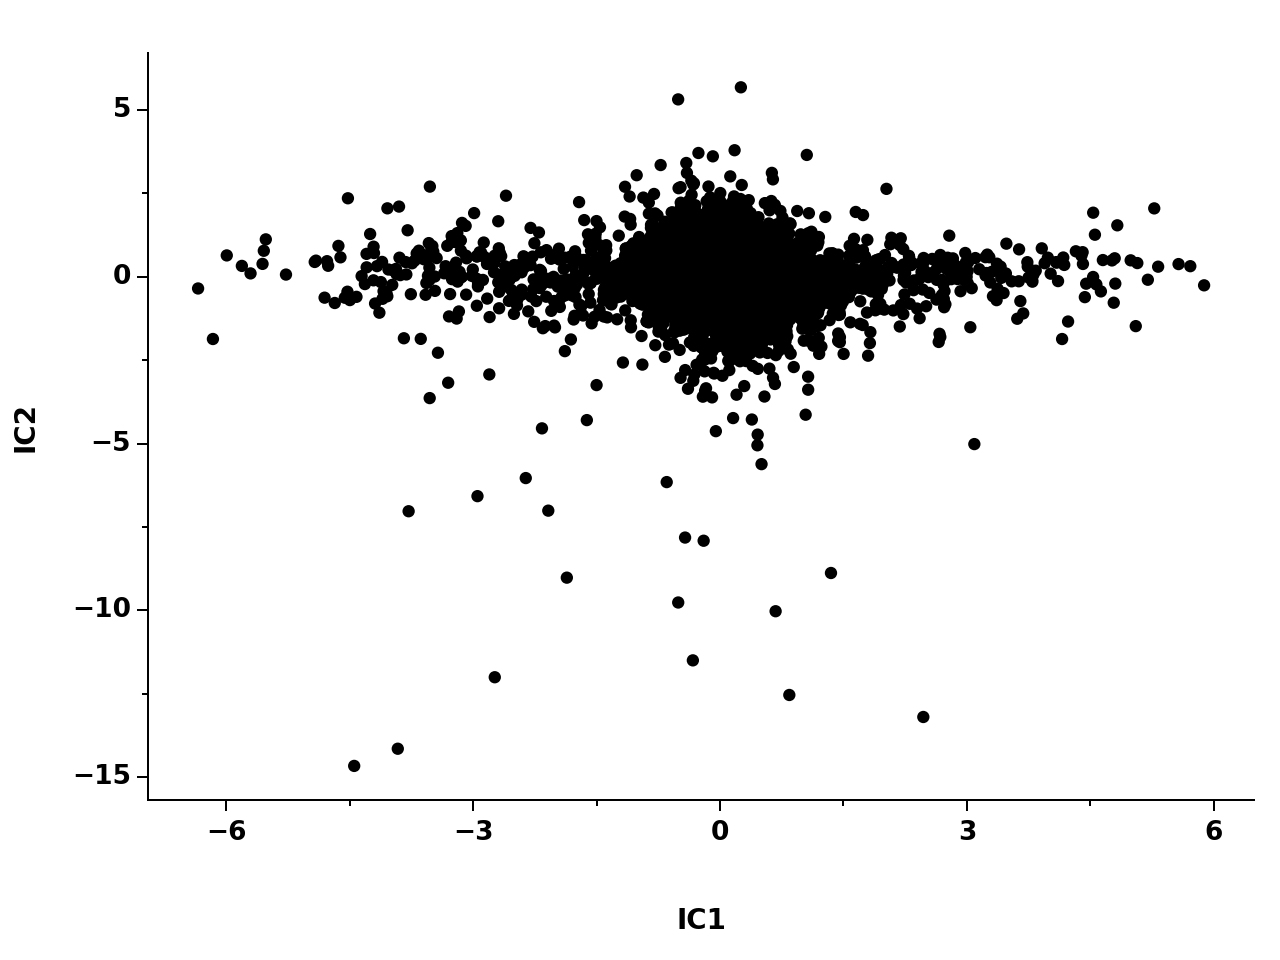

<Figure Size: (640 x 480)>

In [89]:
p7 = (
  ggplot(df_ica, aes(x="IC1", y="IC2"))
  + geom_point()
  + theme_prism()
)
p7

###### Reduce genes

In [82]:
Y_ica = FastICA(n_components=50).fit_transform(filtered_df.T)

In [84]:
df_ica2 = pd.DataFrame(Y_ica)
df_ica2.columns = [f"IC{i}" for i in range(1, 51)]
df_ica2.index = filtered_df.columns

In [85]:
df_ica2.shape

(14510, 50)

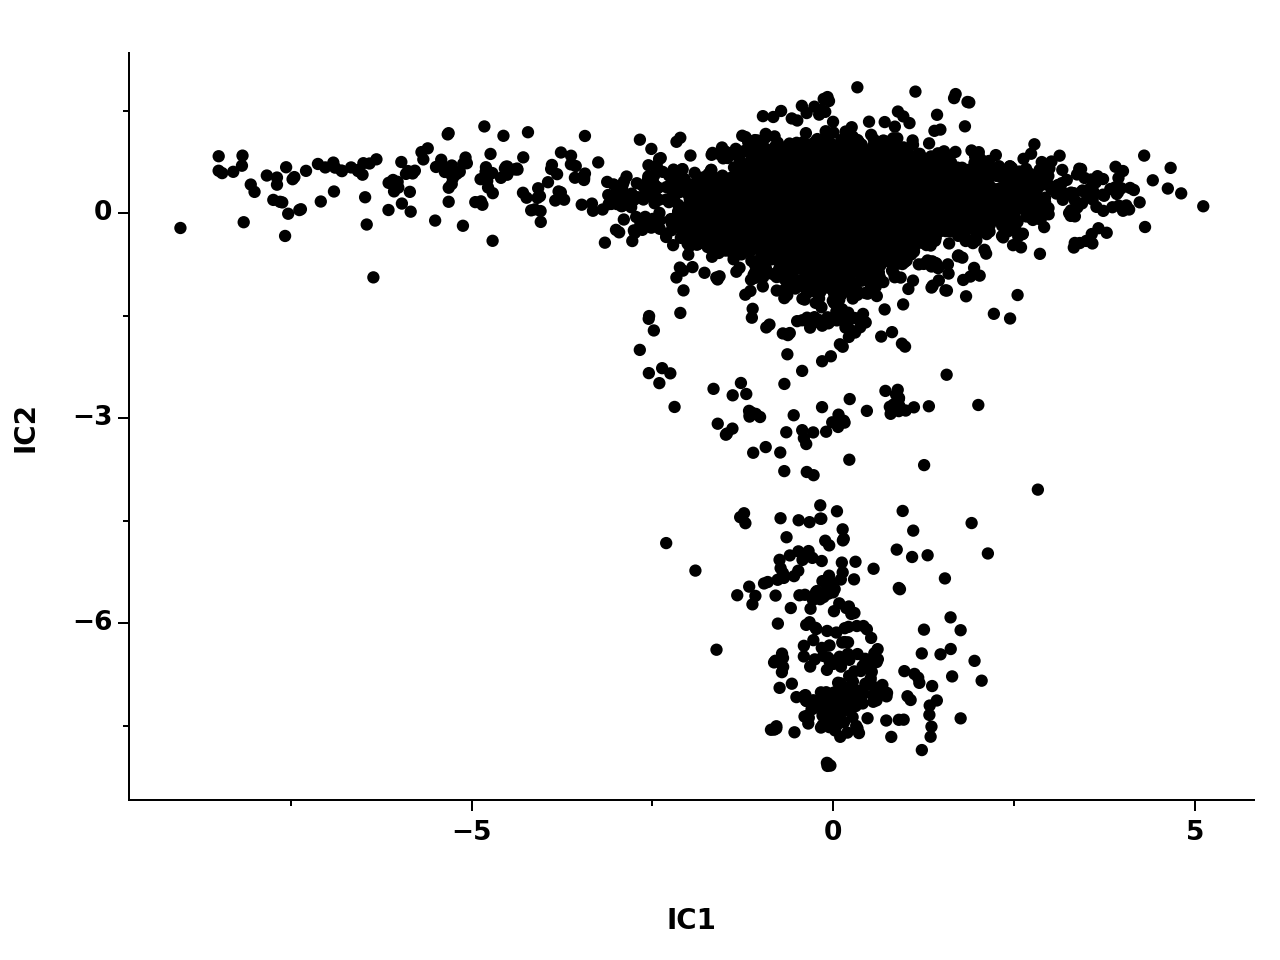

<Figure Size: (640 x 480)>

In [88]:
p8 = (
  ggplot(df_ica2, aes(x="IC1", y="IC2"))
  + geom_point()
  + theme_prism()
)
p8

## 3. Train models

In a previous hyperparameter seach I landed on the following:

* enccoding dimension: 459
* L1 normalizaion: 0
* L2 normalization: 0
* activation functios: tanh
* tied: True
* epochs: 50
* initialization: glorot_uniform
* batch_size: 15
* dropout: 0
* momentum: 0.6
* learning rate: 0.5

In [ ]:
# a dict to store the models
comps = ["ecmg_mgs_lcn01.csv","ecmgp_lcn01.csv"]
model_dict_post = {}

# for timing how long training takes
stime = time.time()
ltime = 0
c = 0

# random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# loop through compendia and random seeds
for comp in comps:
    for seed in seeds:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_mgs_lcn01.csv',
                                                  seed=seed+100,
                                                  enc_dim = 450,
                                                  kl1=0,
                                                  kl2=0,
                                                  act = "tanh",
                                                  act2="tanh",
                                                  tied = True,
                                                  epochs=100,
                                                  init="glorot_uniform",
                                                  batch_size=15,
                                                  dropout = 0,
                                                  mm = 0.6,
                                                  lr = 0.5)
        mseq = sa.train_model()
        temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_post[name] = temp
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

ad_ecmg_mgs_lcn01.csv_2025_09_01_100
Epoch 1/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0183 - val_loss: 0.0134
Epoch 2/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0129 - val_loss: 0.0126
Epoch 3/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0124 - val_loss: 0.0122
Epoch 4/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0120 - val_loss: 0.0120
Epoch 5/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0118 - val_loss: 0.0119
Epoch 6/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0117 - val_loss: 0.0118
Epoch 7/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0116 - val_loss: 0.0117
Epoch 8/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0115 - val_loss: 0.0116
Epoch 9/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0114 - val_loss: 0.0115
Epoch 10/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0113 - val_loss: 0.0115
Epoch 11/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0113 - val_loss: 0.0114
Epoc

In [ ]:
print(rtime)
print(c)
print(ltime / c)
print(rtime / 60)

2222.3970215320587
6
370.3973372777303
37.03995035886764


## 4. Plot training loss

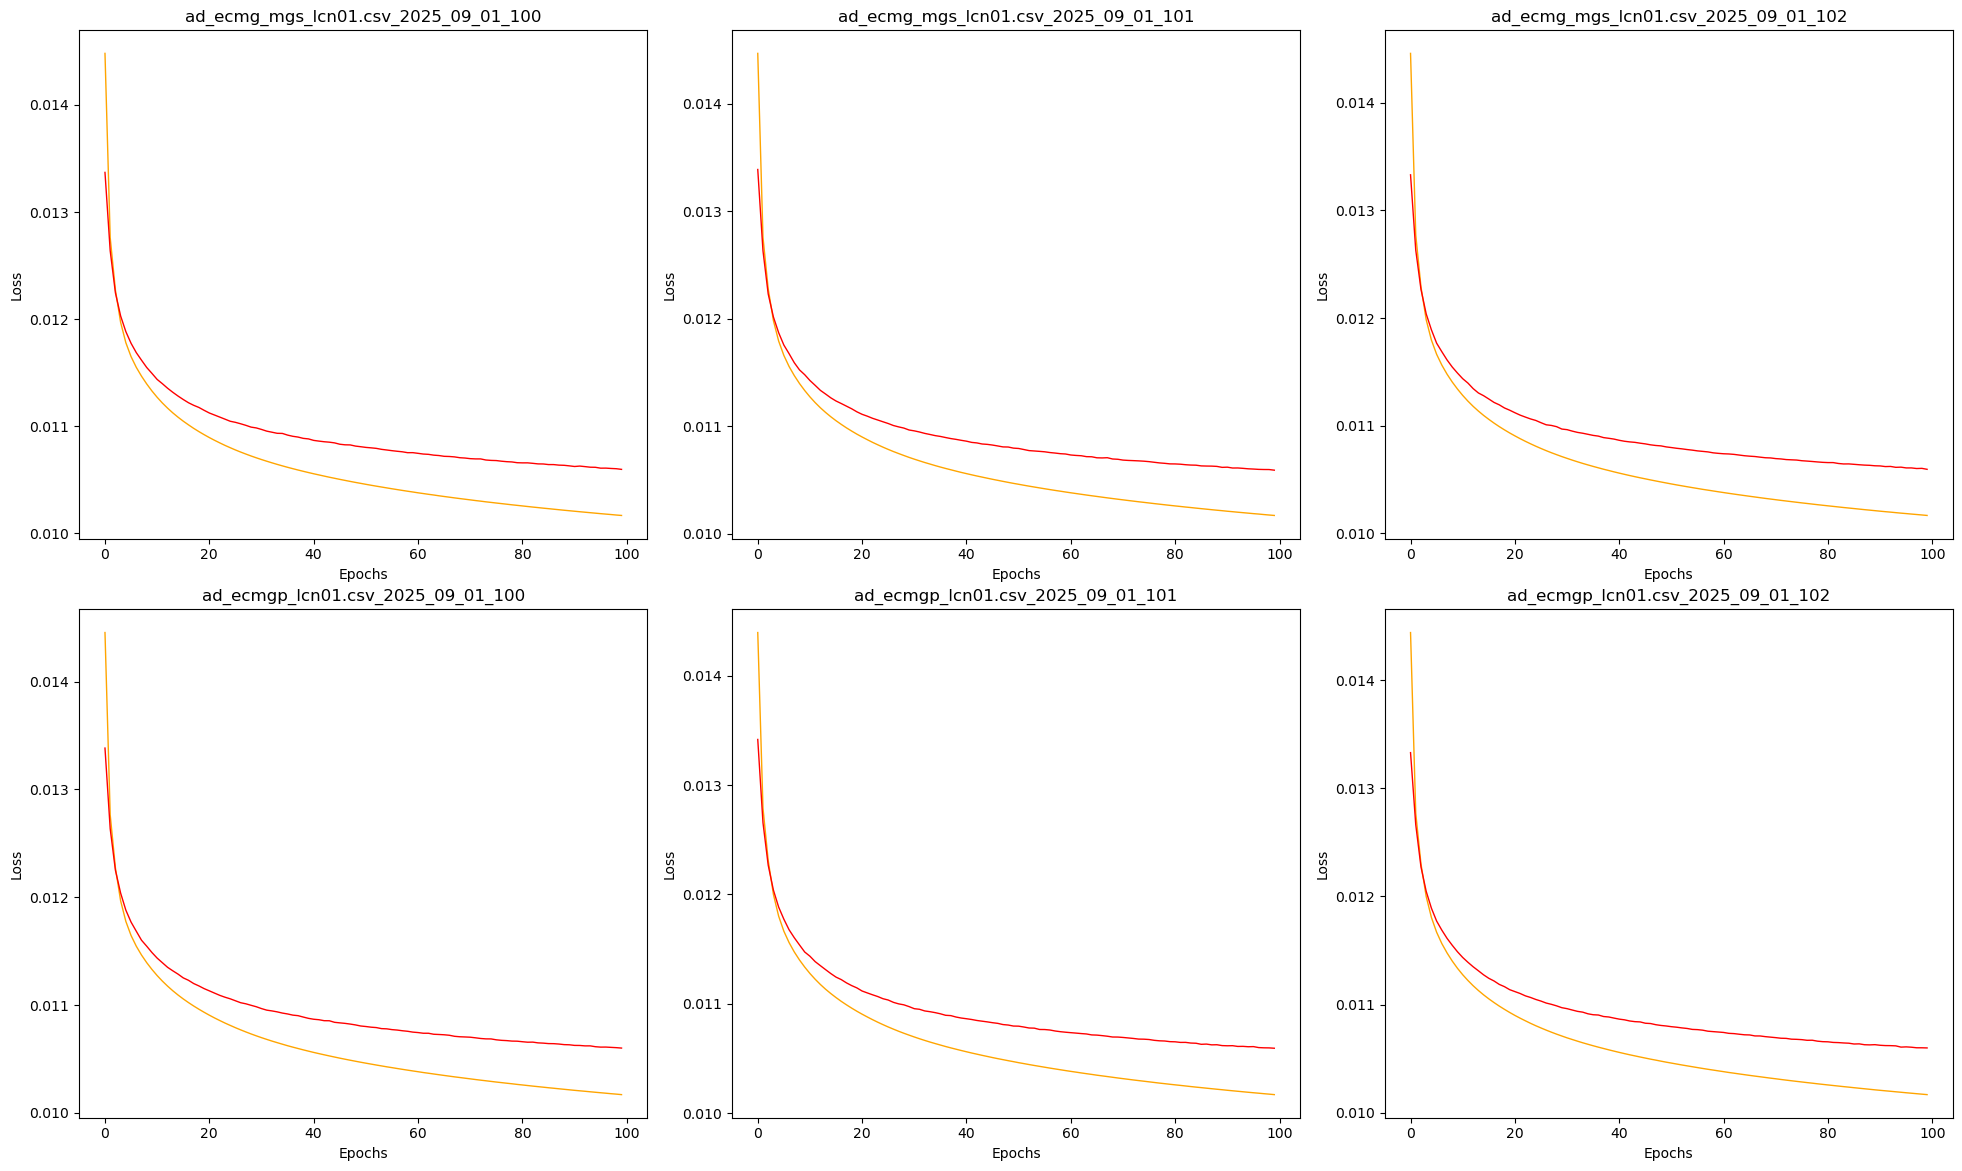

In [ ]:
# set layout for panels of compendia and seeds
xd = len(comps)
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(xd*10 ,yd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for comp in comps:
    xi=0
    for seed in seeds:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        # training loss in orange
        ax[yi,xi].plot(list(range(0,100)), model_temp.loss, linewidth=1,
                       markersize=2, color = 'orange')
        # cross validation loss in red
        ax[yi,xi].plot(list(range(0,100)), model_temp.val_loss,
                       linewidth=1, markersize=2, color = 'red')
        ax[yi,xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
        xi+=1
    yi+=1

## 5. Plot weight distributions

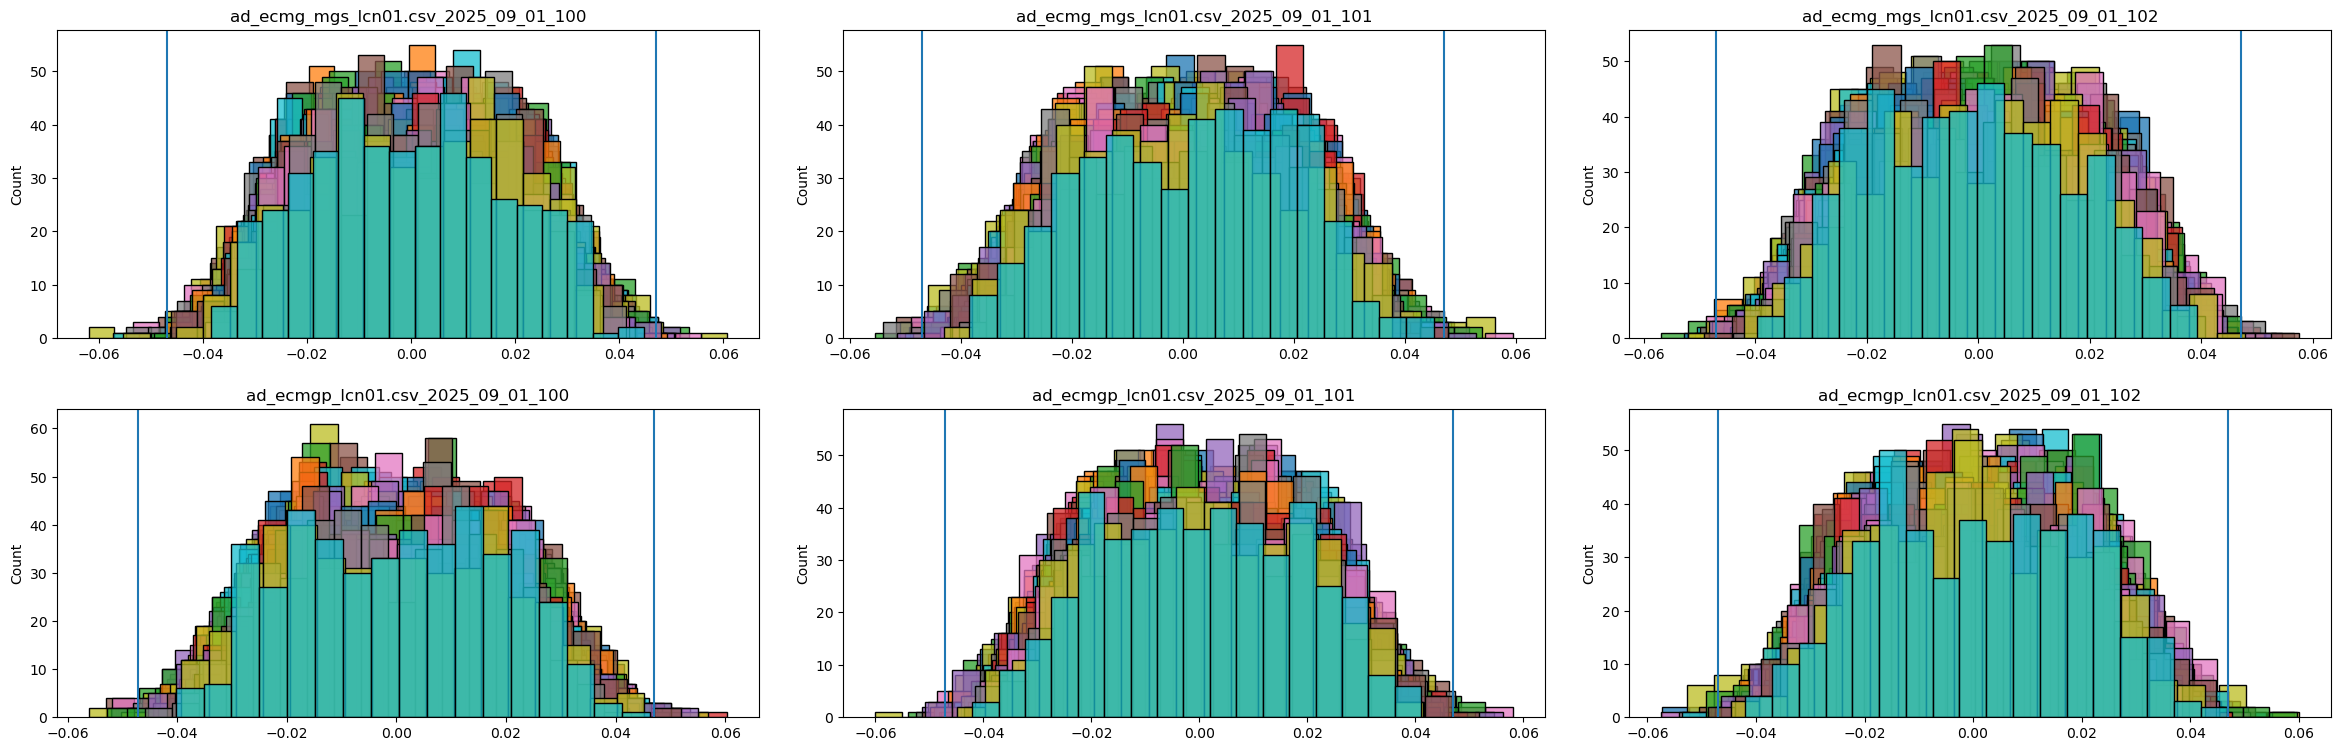

In [ ]:
# set layout for panels of compendia and seeds
xd = len(comps)
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for seed in seeds:
    xi=0
    for comp in comps:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        for node in range(0,100):
            # in each hist, color each hidden node vector distribution
            sns.histplot(model_temp.weights[node],
                ax=ax[xi,yi],
                binwidth = 0.005,
                kde=False)
        # add markers for height/low weight cutoffs
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
        ax[xi,yi].set(title = name)
        xi+=1
    yi+=1